figs9  

生成的nc文件在path_part1_data，fig_s9_xx_sampingmap, 是网格化的采样图，数值是n_sum，样本的个数（但是要注意有些样本来自同一只生物）  
生成的svg在path_part1_fig，名称格式：'fig_s9_bar_xx_year_sampingnum.svg'  
将nc和svg拼合成s9  

In [ ]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import myfunction as mf
import os
from netCDF4 import Dataset
from path_config import *
import seaborn as sns
import matplotlib.pyplot as plt


def lat_lon_to_grid(lat, lon, grid_size=1):
    return round(lat / grid_size) * grid_size, round(lon / grid_size) * grid_size

def change_to_nc(path_final, path_data, data_type, str_colname='value'):
    name_new_file = f'fig_s9_{data_type[0:2]}_sampingmap.nc'
    df = pd.read_csv(path_data + data_type + '.csv')
    df = df[['lon', 'lat', str_colname]]
    nc_file = Dataset(path_final + name_new_file, 'w', format='NETCDF4')

    lon = np.arange(-180, 180, 1)
    lat = np.arange(-90, 90, 1)

    nc_file.createDimension('lon', len(lon))
    nc_file.createDimension('lat', len(lat))


    lon_var = nc_file.createVariable('lon', 'f4', 'lon')
    lat_var = nc_file.createVariable('lat', 'f4', 'lat')


    lon_var[:] = lon
    lat_var[:] = lat


    value_var = nc_file.createVariable(str_colname, 'f4', ('lat', 'lon'))


    value_data = np.full((len(lat), len(lon)), np.nan)
    for index, row in df.iterrows():
        if row['lon'] != -180 and row['lon'] != 180 and row['lat'] != -90 and row['lat'] != 90:

            value_data[int(row['lat'] + 90), int(row['lon'] + 180)] = row[str_colname]
    value_var[:, :] = value_data

    nc_file.close()
    return print('over')

def draw_year_num(df_data, save_path, y_max, x_str, y_str):
    df_bar = df_data.copy()

    sns.set_theme(style="ticks")
    f, ax = plt.subplots(figsize=(12, 4))

    sns.set_color_codes("muted")
    sns.barplot(x=x_str, y=y_str, data=df_bar,
                label="Data volume", color="b")


    ax.set_yscale("log")
    ax.set(ylim=(0, y_max), xlabel="", ylabel="")
    ax.yaxis.grid(True)

    ax.set_ylabel("Number", fontsize=18)  # 设置 y 轴标题的字体大小
    plt.yticks(fontsize=16)
    plt.xticks(fontsize=16, rotation=90)
    plt.rcParams['font.family'] = 'Arial'
    plt.subplots_adjust(left=0.1,right=0.95,bottom=0.21,top=0.8)
    plt.savefig(save_path, dpi = 300)
    sns.despine(right=True, top=True)



### nc

In [ ]:
import pandas as pd

lr_outlier = pd.read_csv(path_part0_temp + 'lr_outlier.csv')
sw_outlier = pd.read_csv(path_part0_temp + 'sw_outlier.csv')

df_fish_use_full =  mf.df_merge_lat_lon(lr_outlier)
df_sw_use_full =  mf.df_merge_lat_lon(sw_outlier)

print(len(df_fish_use_full['lat_lon'].unique().tolist()))
print(len(df_sw_use_full['lat_lon'].unique().tolist()))


print('fish n sum:', df_fish_use_full['n'].sum())
print('water n sum:', df_sw_use_full['n'].sum())


lr_outlier[['lat_grid', 'lon_grid']] = lr_outlier.apply(lambda row: lat_lon_to_grid(row['lat'], row['lon']), axis=1, result_type='expand')
sw_outlier[['lat_grid', 'lon_grid']] = sw_outlier.apply(lambda row: lat_lon_to_grid(row['lat'], row['lon']), axis=1, result_type='expand')

lr_outlier_grouped = lr_outlier.groupby(['lat_grid', 'lon_grid'])['n'].sum().reset_index().rename(columns={'n': 'n_sum'})
sw_outlier_grouped = sw_outlier.groupby(['lat_grid', 'lon_grid'])['n'].sum().reset_index().rename(columns={'n': 'n_sum'})

lr_outlier_grouped = lr_outlier_grouped.rename(columns={'lat_grid': 'lat', 'lon_grid': 'lon'})
sw_outlier_grouped = sw_outlier_grouped.rename(columns={'lat_grid': 'lat', 'lon_grid': 'lon'})


print('fish crd num:',lr_outlier_grouped.shape)
print('water crd num:',sw_outlier_grouped.shape)
lr_outlier_grouped.to_csv(path_part0_temp + 'lr_outlier_group.csv',index=False)
sw_outlier_grouped.to_csv(path_part0_temp + 'sw_outlier_group.csv',index=False)

1434
5684
fish n sum: 72091
water n sum: 114503
fish crd num: (495, 3)
water crd num: (1277, 3)


In [ ]:

df_grid_re = pd.read_csv(path_parts_data + 'grid_re.csv')


df_group_lr = pd.read_csv(path_part0_temp + 'lr_outlier_group.csv')
df_group_sw = pd.read_csv(path_part0_temp + 'sw_outlier_group.csv')

lr_merged_df = pd.merge(df_group_lr, df_grid_re, on=['lon', 'lat'], how='left')
sw_merged_df = pd.merge(df_group_sw, df_grid_re, on=['lon', 'lat'], how='left')


print('fish country_id num:', lr_merged_df['country_id'].nunique()-1)
print('water country_id num:', sw_merged_df['country_id'].nunique()-1)
print('fish ocean_water unique:', lr_merged_df['ocean_water'].unique())
print('water ocean_water unique:', sw_merged_df['ocean_water'].unique())

print('fish ocean_water ratio:\n', lr_merged_df['ocean_water'].value_counts(normalize=True))
print('water ocean_water ratio:\n', sw_merged_df['ocean_water'].value_counts(normalize=True))

print('fish inland_water ratio:\n', lr_merged_df['inland_water'].value_counts(normalize=True))
print('water inland_water ratio:\n', sw_merged_df['inland_water'].value_counts(normalize=True))

fish country_id num: 35
water country_id num: 90
fish ocean_water unique: [1 0]
water ocean_water unique: [0 1]
fish ocean_water ratio:
 1    0.969697
0    0.030303
Name: ocean_water, dtype: float64
water ocean_water ratio:
 1    0.713391
0    0.286609
Name: ocean_water, dtype: float64
fish inland_water ratio:
 0    0.971717
1    0.028283
Name: inland_water, dtype: float64
water inland_water ratio:
 0    0.803446
1    0.196554
Name: inland_water, dtype: float64


In [21]:
path_final = 'E:/wyy/code_project/running_outcome/final_data/SPDB/part1_describe/sample_map/'
path_data = 'E:/wyy/code_project/running_outcome/final_data/SPDB/part1_describe/sample_map/data/'
list_data_type = ['sw_outlier_group', 'lr_outlier_group']
list_value_type = ['n_sum']

for value_type in list_value_type:
    for data_type in list_data_type:
        change_to_nc(path_part1_data, path_part0_temp, data_type, value_type)



over
over


### svg

72091


C:\Users\dell\AppData\Local\Temp\ipykernel_6980\1728868952.py:20: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set(ylim=(0, y_max), xlabel="", ylabel="")


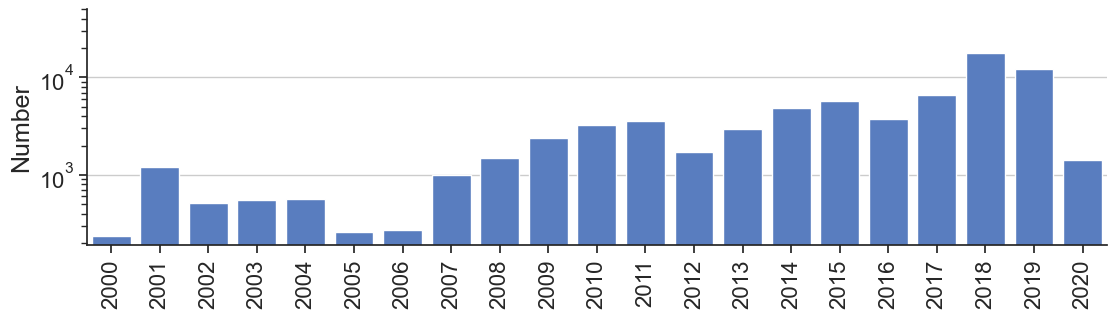

In [ ]:
lr_outlier = pd.read_csv(path_part0_temp + 'lr_outlier.csv')
lr_outlier['year'] = lr_outlier['year'].astype(int)
print('samping num sum:',lr_outlier['n'].sum())
df_lr_year_gb = lr_outlier.groupby(["year"],as_index=False).agg(n=("n","sum"))
lr_save_path = path_part1_fig + 'fig_s9_bar_lr_year_sampingnum.svg'
draw_year_num(df_lr_year_gb, lr_save_path, 50000, 'year', 'n')

samping num sum: 114503


C:\Users\dell\AppData\Local\Temp\ipykernel_6980\1728868952.py:20: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set(ylim=(0, y_max), xlabel="", ylabel="")


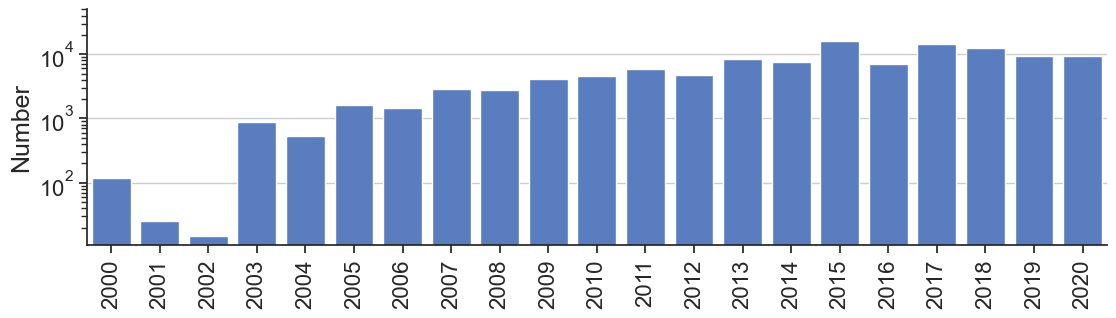

In [16]:
sw_outlier = pd.read_csv(path_part0_temp + 'sw_outlier.csv')
sw_outlier['year'] = sw_outlier['year'].astype(int)
print('samping num sum:',sw_outlier['n'].sum())
df_sw_year_gb = sw_outlier.groupby(["year"],as_index=False).agg(n=("n","sum"))
sw_save_path = path_part1_fig + 'fig_s9_bar_sw_year_sampingnum.svg'
draw_year_num(df_sw_year_gb, sw_save_path, 50000, 'year', 'n')